# Packet and Flowlet Direction Comparison

This notebook compares incoming vs outgoing traffic at two levels:

- **Packet totals** for `llm` and `non_llm` traffic
- **Flowlet counts** for `non_llm` traffic, to compare with the LLM flowlet-direction result from the paper

Because the same base captures appear at multiple flowlet thresholds, the primary plots below use a **single threshold** at a time so captures are not counted multiple times.


In [7]:
import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="crest")


def load_latest_snapshot() -> tuple[Path, pd.DataFrame]:
    candidate_roots = [
        Path("data-pipeline/data/snapshots"),
        Path("../data-pipeline/data/snapshots"),
    ]

    snapshots_root = None
    snapshot_dirs = []
    for candidate in candidate_roots:
        candidate_dirs = sorted(candidate.glob("snapshot_*"), reverse=True)
        if candidate_dirs:
            snapshots_root = candidate
            snapshot_dirs = candidate_dirs
            break

    if not snapshot_dirs or snapshots_root is None:
        checked = ", ".join(str(path.resolve()) for path in candidate_roots)
        raise FileNotFoundError(f"No snapshots found. Checked: {checked}")

    snapshot_dir = snapshot_dirs[0]
    captures_dir = snapshot_dir / "captures"
    capture_files = sorted(captures_dir.glob("*.json"))

    rows = []
    for fpath in capture_files:
        with open(fpath, "r", encoding="utf-8") as f:
            doc = json.load(f)

        cap_id = str(doc.get("_id", fpath.stem))
        file_path = doc.get("file_path", cap_id)
        match = re.search(r"_(\d+\.?\d*)$", file_path)
        threshold = doc.get("threshold")
        base_name = file_path[:match.start()] if match else file_path

        for fl in doc.get("flowlets") or []:
            fk = fl.get("flow_key", {})
            rows.append({
                "capture_id": cap_id,
                "base_capture": base_name,
                "threshold": threshold,
                "file_path": file_path,
                "traffic_class": fl.get("traffic_class"),
                "llm_name": fl.get("llm_name"),
                "outgoing": fl.get("outgoing"),
                "direction_encoded": fl.get("direction_encoded", 0),
                "flowlet_id": fl.get("flowlet_id"),
                "duration": fl.get("duration", 0),
                "packet_count": fl.get("packet_count", 0),
                "total_bytes": fl.get("total_bytes", 0),
                "packet_size_mean": fl.get("packet_size_mean"),
                "packet_size_std": fl.get("packet_size_std"),
                "inter_packet_time_mean": fl.get("inter_packet_time_mean"),
                "inter_packet_time_std": fl.get("inter_packet_time_std"),
                "src_ip": fk.get("src_ip"),
                "dst_ip": fk.get("dst_ip"),
                "protocol": fk.get("protocol"),
            })

    df = pd.DataFrame(rows)
    return snapshot_dir, df


snapshot_dir, df = load_latest_snapshot()
available_thresholds = sorted(df["threshold"].dropna().unique().tolist())
print(f"Using snapshot: {snapshot_dir.name}")
print(f"Loaded {len(df):,} flowlets from {df['capture_id'].nunique():,} captures")
print(f"Available thresholds: {available_thresholds}")
df.head()


Using snapshot: snapshot_20260416_163332
Loaded 674,852 flowlets from 117 captures
Available thresholds: [0.05, 0.1, 0.2]


,capture_id,base_capture,threshold,file_path,traffic_class,llm_name,outgoing,direction_encoded,flowlet_id,duration,packet_count,total_bytes,packet_size_mean,packet_size_std,inter_packet_time_mean,inter_packet_time_std,src_ip,dst_ip,protocol
0,3-19-26-non-llm-10-min_0.05,3-19-26-non-llm-10-min,0.05,3-19-26-non-llm-10-min_0.05,non_llm,None,None,0,1,0.006761,19,16727,880.368421,612.043318,0.000376,0.000690,17.250.96.198,172.25.168.55,6
1,3-19-26-non-llm-10-min_0.05,3-19-26-non-llm-10-min,0.05,3-19-26-non-llm-10-min_0.05,non_llm,None,None,0,2,0.007671,3,2126,708.666667,689.006047,0.003835,0.005402,172.25.168.55,17.250.96.198,6
2,3-19-26-non-llm-10-min_0.05,3-19-26-non-llm-10-min,0.05,3-19-26-non-llm-10-min_0.05,non_llm,None,None,0,3,0.028227,92,81313,883.836957,584.693613,0.000310,0.001028,17.250.96.198,172.25.168.55,6
3,3-19-26-non-llm-10-min_0.05,3-19-26-non-llm-10-min,0.05,3-19-26-non-llm-10-min_0.05,non_llm,None,None,0,1,0.014345,3,1210,403.333333,557.373603,0.007173,0.010064,172.25.168.55,98.124.193.103,6
4,3-19-26-non-llm-10-min_0.05,3-19-26-non-llm-10-min,0.05,3-19-26-non-llm-10-min_0.05,non_llm,None,None,0,2,0.038493,6,2417,402.833333,497.761556,0.007699,0.010234,172.25.168.55,98.124.193.103,6


## Core Dataset Distribution Summary

The table-style summary below reproduces the high-level dataset moments directly from the loaded snapshot, and the empirical CDF plots add the missing distribution shape information. This makes it easier to see skew, tails, and class overlap that mean/median/std alone can hide.


Traffic class,Flowlets,Dur. mean,Pkts mean,Bytes mean
All flowlets,"674,852",0.082,21.072,"15,001"
LLM,"334,428",0.061,16.875,"13,260"
Non-LLM,"340,424",0.102,25.195,"16,711"


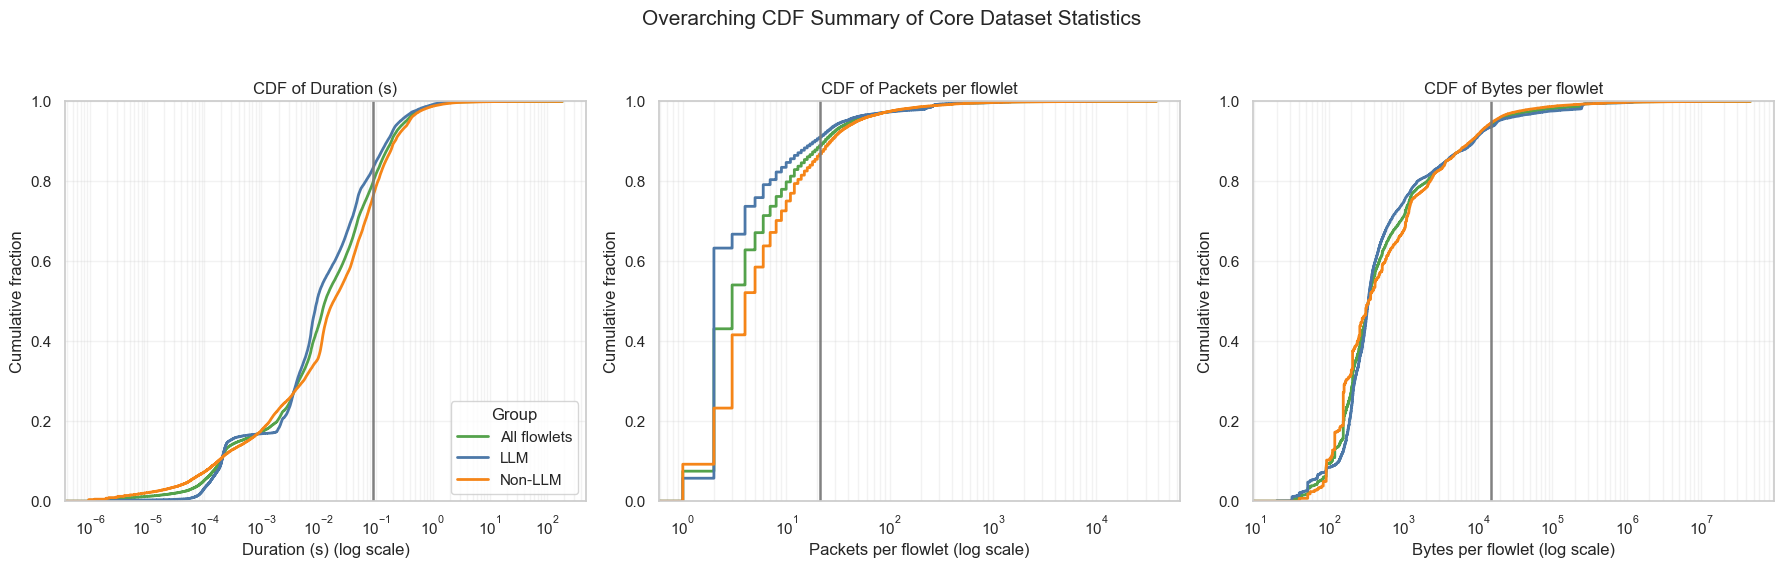

In [13]:
core_df = df[df["traffic_class"].isin(["llm", "non_llm"])].copy()
core_df["traffic_class_label"] = core_df["traffic_class"].map({"llm": "LLM", "non_llm": "Non-LLM"})

core_stats = pd.DataFrame(
    [
        {
            "Traffic class": "All flowlets",
            "Flowlets": len(core_df),
            "Dur. mean": core_df["duration"].mean(),
            "Pkts mean": core_df["packet_count"].mean(),
            "Bytes mean": core_df["total_bytes"].mean(),
        },
        {
            "Traffic class": "LLM",
            "Flowlets": (core_df["traffic_class"] == "llm").sum(),
            "Dur. mean": core_df.loc[core_df["traffic_class"] == "llm", "duration"].mean(),
            "Pkts mean": core_df.loc[core_df["traffic_class"] == "llm", "packet_count"].mean(),
            "Bytes mean": core_df.loc[core_df["traffic_class"] == "llm", "total_bytes"].mean(),
        },
        {
            "Traffic class": "Non-LLM",
            "Flowlets": (core_df["traffic_class"] == "non_llm").sum(),
            "Dur. mean": core_df.loc[core_df["traffic_class"] == "non_llm", "duration"].mean(),
            "Pkts mean": core_df.loc[core_df["traffic_class"] == "non_llm", "packet_count"].mean(),
            "Bytes mean": core_df.loc[core_df["traffic_class"] == "non_llm", "total_bytes"].mean(),
        },
    ]
)

display(
    core_stats.style.format({
        "Flowlets": "{:,.0f}",
        "Dur. mean": "{:.3f}",
        "Pkts mean": "{:.3f}",
        "Bytes mean": "{:,.0f}",
    }).hide(axis="index").set_caption("Core dataset statistics from the current snapshot")
)

cdf_specs = [
    ("duration", "Duration (s)", True),
    ("packet_count", "Packets per flowlet", True),
    ("total_bytes", "Bytes per flowlet", True),
]

plot_frames = [
    ("All flowlets", core_df),
    ("LLM", core_df[core_df["traffic_class"] == "llm"]),
    ("Non-LLM", core_df[core_df["traffic_class"] == "non_llm"]),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
color_map = {
    "All flowlets": "#54A24B",
    "LLM": "#4C78A8",
    "Non-LLM": "#F58518",
}

for ax, (metric, label, use_log_scale) in zip(axes, cdf_specs):
    all_metric_df = None

    for class_label, subset in plot_frames:
        metric_df = subset[[metric]].dropna()
        if use_log_scale:
            metric_df = metric_df[metric_df[metric] > 0]

        sns.ecdfplot(
            data=metric_df,
            x=metric,
            ax=ax,
            label=class_label,
            linewidth=2,
            color=color_map[class_label],
        )

        if class_label == "All flowlets":
            all_metric_df = metric_df

    if all_metric_df is not None and not all_metric_df.empty:
        metric_mean = all_metric_df[metric].mean()
        metric_std = all_metric_df[metric].std()
        min_positive = all_metric_df[metric].min()

        if pd.notna(metric_mean) and metric_mean > 0:
            ax.axvline(metric_mean, color="#7A7A7A", linewidth=1.8, alpha=0.95, linestyle="-")

    ax.set_title(f"CDF of {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("Cumulative fraction")
    if use_log_scale:
        ax.set_xscale("log")
        ax.set_xlabel(f"{label} (log scale)")
    ax.grid(True, which="both", alpha=0.25)

axes[0].legend(title="Group", loc="lower right")
fig.suptitle("Overarching CDF Summary of Core Dataset Statistics", fontsize=15, y=1.03)
plt.tight_layout()
plt.show()


In [3]:
# Pick a single threshold to avoid counting the same base capture multiple times.
# Change this to 0.05 or 0.1 if you want to compare a different flowlet construction.
ANALYSIS_THRESHOLD = 0.2

if ANALYSIS_THRESHOLD not in available_thresholds:
    raise ValueError(f"Threshold {ANALYSIS_THRESHOLD} not present. Choose from {available_thresholds}.")

plot_df = df[df["threshold"] == ANALYSIS_THRESHOLD].copy()
plot_df = plot_df[plot_df["traffic_class"].isin(["llm", "non_llm"])].copy()
plot_df["direction"] = plot_df["outgoing"].map({True: "Outgoing", False: "Incoming"})
plot_df = plot_df.dropna(subset=["direction"])
plot_df["traffic_class_label"] = plot_df["traffic_class"].map({"llm": "LLM", "non_llm": "Non-LLM"})

packet_direction = (
    plot_df.groupby(["traffic_class", "traffic_class_label", "direction"], as_index=False)["packet_count"]
    .sum()
)

flowlet_direction = (
    plot_df.groupby(["traffic_class", "traffic_class_label", "direction"], as_index=False)
    .size()
    .rename(columns={"size": "flowlet_count"})
)

llm_flowlet_direction = (
    flowlet_direction[flowlet_direction["traffic_class"] == "llm"]
    [["traffic_class_label", "direction", "flowlet_count"]]
    .reset_index(drop=True)
)

non_llm_flowlet_direction = (
    flowlet_direction[flowlet_direction["traffic_class"] == "non_llm"]
    [["traffic_class_label", "direction", "flowlet_count"]]
    .reset_index(drop=True)
)

packet_summary = (
    packet_direction
    .pivot(index="traffic_class_label", columns="direction", values="packet_count")
    .fillna(0)
)
packet_summary["Total"] = packet_summary.sum(axis=1)
packet_summary["Outgoing share"] = packet_summary["Outgoing"] / packet_summary["Total"]
packet_summary["Incoming share"] = packet_summary["Incoming"] / packet_summary["Total"]
packet_summary["Outgoing / Incoming"] = packet_summary["Outgoing"] / packet_summary["Incoming"]

flowlet_summary = (
    flowlet_direction
    .pivot(index="traffic_class_label", columns="direction", values="flowlet_count")
    .fillna(0)
)
flowlet_summary["Total"] = flowlet_summary.sum(axis=1)
flowlet_summary["Outgoing share"] = flowlet_summary["Outgoing"] / flowlet_summary["Total"]
flowlet_summary["Incoming share"] = flowlet_summary["Incoming"] / flowlet_summary["Total"]
flowlet_summary["Outgoing / Incoming"] = flowlet_summary["Outgoing"] / flowlet_summary["Incoming"]

display(packet_summary.style.format({
    "Incoming": "{:,.0f}",
    "Outgoing": "{:,.0f}",
    "Total": "{:,.0f}",
    "Outgoing share": "{:.1%}",
    "Incoming share": "{:.1%}",
    "Outgoing / Incoming": "{:.2f}x",
}).set_caption(f"Packet totals at threshold = {ANALYSIS_THRESHOLD:g} s"))

display(flowlet_summary.style.format({
    "Incoming": "{:,.0f}",
    "Outgoing": "{:,.0f}",
    "Total": "{:,.0f}",
    "Outgoing share": "{:.1%}",
    "Incoming share": "{:.1%}",
    "Outgoing / Incoming": "{:.2f}x",
}).set_caption(f"Flowlet counts at threshold = {ANALYSIS_THRESHOLD:g} s"))


direction,Incoming,Outgoing,Total,Outgoing share,Incoming share,Outgoing / Incoming
traffic_class_label,,,,,,
LLM,"619,208","1,138,977","1,758,185",64.8%,35.2%,1.84x
Non-LLM,"824,126","21,984","846,110",2.6%,97.4%,0.03x


direction,Incoming,Outgoing,Total,Outgoing share,Incoming share,Outgoing / Incoming
traffic_class_label,,,,,,
LLM,"38,758","40,535","79,293",51.1%,48.9%,1.05x
Non-LLM,"46,916","3,084","50,000",6.2%,93.8%,0.07x


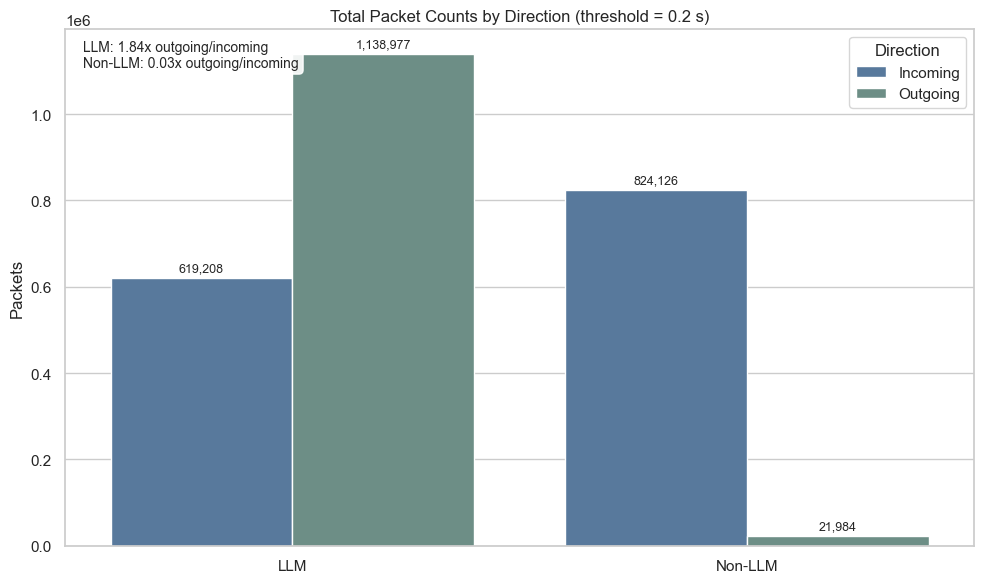

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

packet_plot = packet_direction.copy()
packet_plot["direction"] = pd.Categorical(packet_plot["direction"], ["Incoming", "Outgoing"], ordered=True)
packet_plot["traffic_class_label"] = pd.Categorical(packet_plot["traffic_class_label"], ["LLM", "Non-LLM"], ordered=True)
packet_plot = packet_plot.sort_values(["traffic_class_label", "direction"])

sns.barplot(
    data=packet_plot,
    x="traffic_class_label",
    y="packet_count",
    hue="direction",
    hue_order=["Incoming", "Outgoing"],
    palette=["#4C78A8", "#689389"],
    ax=ax,
)
ax.set_title(f"Total Packet Counts by Direction (threshold = {ANALYSIS_THRESHOLD:g} s)")
ax.set_xlabel("")
ax.set_ylabel("Packets")
ax.legend(title="Direction")

for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3, fontsize=9)

ratio_text = []
for class_label in ["LLM", "Non-LLM"]:
    incoming = packet_summary.loc[class_label, "Incoming"]
    outgoing = packet_summary.loc[class_label, "Outgoing"]
    ratio = outgoing / incoming if incoming else float("inf")
    ratio_text.append(f"{class_label}: {ratio:.2f}x outgoing/incoming")

ax.text(
    0.02,
    0.98,
    "\n".join(ratio_text),
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9},
)

plt.tight_layout()
plt.show()


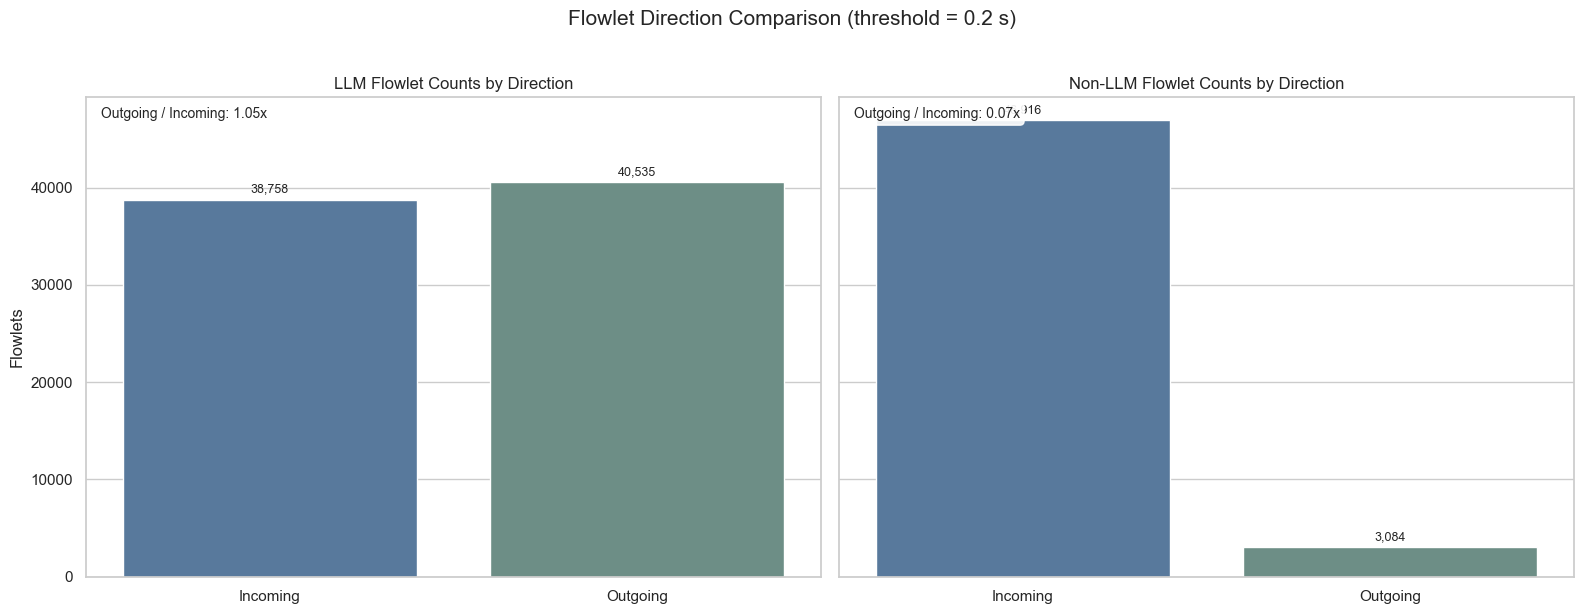

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

flowlet_plots = [
    (axes[0], llm_flowlet_direction.copy(), "LLM Flowlet Counts by Direction"),
    (axes[1], non_llm_flowlet_direction.copy(), "Non-LLM Flowlet Counts by Direction"),
]

for ax, flowlet_plot, title in flowlet_plots:
    flowlet_plot["direction"] = pd.Categorical(flowlet_plot["direction"], ["Incoming", "Outgoing"], ordered=True)
    flowlet_plot = flowlet_plot.sort_values("direction")

    sns.barplot(
        data=flowlet_plot,
        x="direction",
        y="flowlet_count",
        order=["Incoming", "Outgoing"],
        palette=["#4C78A8", "#689389"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Flowlets")

    for container in ax.containers:
        ax.bar_label(container, fmt="{:,.0f}", padding=3, fontsize=9)

    class_label = flowlet_plot["traffic_class_label"].iloc[0]
    ratio = flowlet_summary.loc[class_label, "Outgoing / Incoming"]
    ax.text(
        0.02,
        0.98,
        f"Outgoing / Incoming: {ratio:.2f}x",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10,
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9},
    )

fig.suptitle(f"Flowlet Direction Comparison (threshold = {ANALYSIS_THRESHOLD:g} s)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


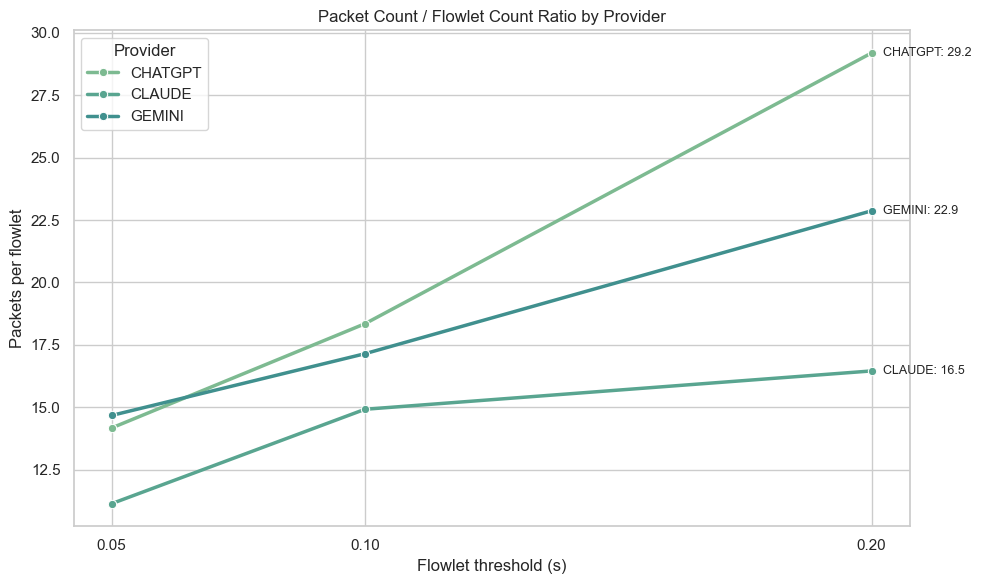

,threshold,llm_name,flowlet_count,total_packets,packets_per_flowlet
0,0.05,CHATGPT,"42,581","603,399",14.17
3,0.1,CHATGPT,"32,854","602,763",18.35
6,0.2,CHATGPT,"20,778","606,611",29.19
1,0.05,CLAUDE,"39,411","438,958",11.14
4,0.1,CLAUDE,"32,428","483,791",14.92
7,0.2,CLAUDE,"29,102","478,869",16.45
2,0.05,GEMINI,"50,375","739,085",14.67
5,0.1,GEMINI,"39,454","676,449",17.15
8,0.2,GEMINI,"29,413","672,705",22.87


In [6]:
# LLM provider comparison: packets per flowlet across thresholds.
provider_ratio = (
    df[(df["traffic_class"] == "llm") & (df["llm_name"].notna())]
    .groupby(["threshold", "llm_name"], as_index=False)
    .agg(
        flowlet_count=("flowlet_id", "count"),
        total_packets=("packet_count", "sum"),
    )
)
provider_ratio["packets_per_flowlet"] = (
    provider_ratio["total_packets"] / provider_ratio["flowlet_count"]
)
provider_ratio["threshold_label"] = provider_ratio["threshold"].map(lambda t: f"{t:g} s")

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=provider_ratio.sort_values(["llm_name", "threshold"]),
    x="threshold",
    y="packets_per_flowlet",
    hue="llm_name",
    marker="o",
    linewidth=2.5,
    ax=ax,
)

ax.set_title("Packet Count / Flowlet Count Ratio by Provider")
ax.set_xlabel("Flowlet threshold (s)")
ax.set_ylabel("Packets per flowlet")
ax.set_xticks(sorted(provider_ratio["threshold"].dropna().unique()))
ax.legend(title="Provider")

for provider_name, provider_df in provider_ratio.groupby("llm_name"):
    provider_df = provider_df.sort_values("threshold")
    last_row = provider_df.iloc[-1]
    ax.annotate(
        f"{provider_name}: {last_row['packets_per_flowlet']:.1f}",
        xy=(last_row["threshold"], last_row["packets_per_flowlet"]),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

display(
    provider_ratio[["threshold", "llm_name", "flowlet_count", "total_packets", "packets_per_flowlet"]]
    .sort_values(["llm_name", "threshold"])
    .style.format({
        "threshold": "{:g}",
        "flowlet_count": "{:,.0f}",
        "total_packets": "{:,.0f}",
        "packets_per_flowlet": "{:,.2f}",
    })
    .set_caption("LLM provider packet-to-flowlet ratio across thresholds")
)


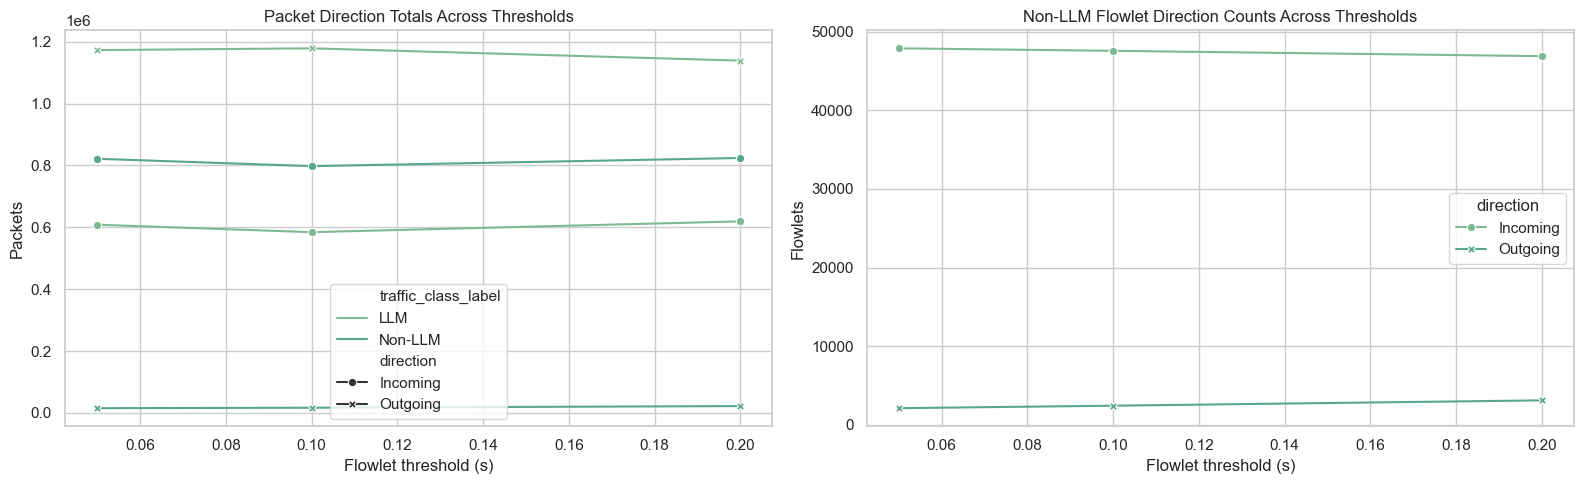

In [12]:
# Optional robustness view: inspect whether the directional pattern changes across thresholds.
robust_packet_direction = (
    df[df["traffic_class"].isin(["llm", "non_llm"])]
    .assign(
        direction=lambda d: d["outgoing"].map({True: "Outgoing", False: "Incoming"}),
        traffic_class_label=lambda d: d["traffic_class"].map({"llm": "LLM", "non_llm": "Non-LLM"}),
    )
    .dropna(subset=["direction", "threshold"])
    .groupby(["threshold", "traffic_class_label", "direction"], as_index=False)["packet_count"]
    .sum()
)

robust_non_llm_flowlets = (
    df[df["traffic_class"] == "non_llm"]
    .assign(direction=lambda d: d["outgoing"].map({True: "Outgoing", False: "Incoming"}))
    .dropna(subset=["direction", "threshold"])
    .groupby(["threshold", "direction"], as_index=False)
    .size()
    .rename(columns={"size": "flowlet_count"})
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(
    data=robust_packet_direction,
    x="threshold",
    y="packet_count",
    hue="traffic_class_label",
    style="direction",
    markers=True,
    dashes=False,
    ax=axes[0],
)
axes[0].set_title("Packet Direction Totals Across Thresholds")
axes[0].set_xlabel("Flowlet threshold (s)")
axes[0].set_ylabel("Packets")

sns.lineplot(
    data=robust_non_llm_flowlets,
    x="threshold",
    y="flowlet_count",
    hue="direction",
    style="direction",
    markers=True,
    dashes=False,
    ax=axes[1],
)
axes[1].set_title("Non-LLM Flowlet Direction Counts Across Thresholds")
axes[1].set_xlabel("Flowlet threshold (s)")
axes[1].set_ylabel("Flowlets")

plt.tight_layout()
plt.show()


### How to read these plots

- If `LLM` traffic shows a much stronger outgoing-vs-incoming packet imbalance than `non_llm`, that suggests the classifier may be picking up request/response asymmetry at the packet level, not just the number of flowlets.
- The `non_llm` flowlet-direction plot gives you the direct baseline to compare against the LLM flowlet-direction result you already have from the paper.
- If you want to stress-test the conclusion, rerun the notebook at `0.05`, `0.1`, and `0.2` seconds and compare how stable the directional ratios are.
